Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
!pip install watermark

In [2]:
!pip install torchinfo

In [3]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.8.0+cu126



# Network-in-Network (NiN) Classifier on CIFAR-10

**Network Architecture:**

Network in Network essentially removed the "parameter-heavy" fully connected layers seen in `AlexNet`, `LeNet` and `VGG` by using **Global Average Pooling** and also introduced **$1\times1$ convolutions.**

![NiN architectire](https://raw.githubusercontent.com/d2l-ai/d2l-en/master/img/nin.svg)

[Source](https://d2l.ai/chapter_convolutional-modern/nin.html)


---
### **Improvements of `NiN` over `LeNet`, `AlexNet`, `VGG`:**

1. **1×1 Convolutions (MLPconv):** `NiN` replaced standard linear convolutional layers with "micro-networks" (MLPs) implemented as **$1\times1$ convolutions** that add local nonlinearities across the channel activations. While `VGG` and `AlexNet` filters only extract spatial features, NiN's $1\times1$ layers allow the model to learn complex non-linear relationships *across channels* at every single pixel location.<br><br>
2. **Global Average Pooling (GAP):** This is NiN's most famous contribution which was used to integrate across all locations in the last representation layer. Instead of using massive "Flatten + Dense" layers at the end of the network (which account for ~90% of AlexNet's parameters), NiN takes the average of each feature map. This drastically reduces the parameter count and acts as a strong regularizer to prevent overfitting. Note that global average pooling would not be effective, were it not for the added nonlinearities.<br><br>
3. **Deep Cross-Channel Pooling:** By stacking multiple $1\times1$ convolutions, NiN performs a form of "channel-wise" dimensionality reduction or expansion. This allows the network to increase its representational power (depth) without the explosive memory cost associated with the large 4096-unit fully connected layers found in VGG.

---

### **Quick Comparison Table**

| Feature | AlexNet / VGG | Network In Network (NiN) |
| --- | --- | --- |
| **Top-level Classifier** | Fully Connected (Dense) Layers | **Global Average Pooling** |
| **Feature Extraction** | Linear Convolutional Filters | **MLPconv (1×1 Convolutions)** |
| **Parameter Density** | Extremely High (due to FC layers) | **Very Low** (more efficient) |
| **Main Innovation** | Deeper stacks of 3x3/5x5 | **Cross-channel non-linearity** |

<br><br>

**REFERENCES:**
1. Lin, M., Chen, Q., & Yan, S. ["Network In Network."](https://arxiv.org/pdf/1312.4400) International Conference on Learning Representations (ICLR), 2014. arXiv:1312.4400.
2. Zhang, Aston, et al. ["Network in Network (NiN) (Chapter 8.3)."](https://d2l.ai/chapter_convolutional-modern/nin.html) _Dive into Deep Learning_. Cambridge University Press, 2023.
3. Google. (2025). ["Gemini 3 Flash"](https://gemini.google.com/) [Large language model]. Google AI.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [5]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [6]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 
LEARNING_RATE = 0.001
NUM_EPOCHS = 80
INPUT_SIZE = 32 # CIFAR-10 is 32x32
NUM_CLASSES = 10

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


---
# 1. Data Preparation & Loading

---

In [7]:
# Mean and Std Dev for CIFAR-10 (3 channels)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2471, 0.2435, 0.2616)

# CIFAR-10 preprocessing
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   
    transforms.RandomHorizontalFlip(),      
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD) 
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Load Datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

# Split training set into training and validation sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

---
# 2. Model Creation

---

In [8]:
def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(inplace=True),
        # The "Network in Network" part: two 1x1 convolutions (MLPs)
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(inplace=True)
    )


class NiN(nn.Module):
    def __init__(self, num_classes=10):
        super(NiN, self).__init__()
        self.net = nn.Sequential(
            nin_block(3, 192, kernel_size=5, strides=1, padding=2),
            nn.MaxPool2d(3, stride=2, padding=1),
            nn.Dropout(0.5),

            nin_block(192, 160, kernel_size=5, strides=1, padding=2),
            nn.MaxPool2d(3, stride=2, padding=1),
            nn.Dropout(0.5),

            nin_block(160, 96, kernel_size=3, strides=1, padding=1),
            nn.MaxPool2d(3, stride=2, padding=1),
            nn.Dropout(0.5),

            # Final block reduces channels to number of classes
            nin_block(96, num_classes, kernel_size=3, strides=1, padding=1),
            # Global Average Pooling replaces Fully Connected layers
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

    def forward(self, x):
        return self.net(x)

print(device)

cuda


In [9]:
def test_model_dims():
    # Create a dummy batch: 2 images, 3 channels, 32x32 size
    x = torch.randn(2, 3, 32, 32).to(device)

    # Initialize model
    net = NiN().to(device)

    # Forward pass
    y = net(x)

    print(f"Input Shape: {x.shape}")
    print(f"Output Shape: {y.shape}") # Should be [2, 10]

    if y.shape == (2, 10):
        print("✅ Sanity Check Passed: Dimensions are correct for CIFAR-10!")
    else:
        print("❌ Sanity Check Failed: Check your stride or pooling layers.")

test_model_dims()

Input Shape: torch.Size([2, 3, 32, 32])
Output Shape: torch.Size([2, 10])
✅ Sanity Check Passed: Dimensions are correct for CIFAR-10!


In [10]:
set_all_seeds(RANDOM_SEED)
model = NiN(num_classes=NUM_CLASSES).to(device)

# Model parameter details
summary(model, 
        input_size=(BATCH_SIZE, 3, INPUT_SIZE, INPUT_SIZE), # verbose=1,
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
       )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
NiN                                      [128, 3, 32, 32]          [128, 10]                 --                        --                        --
├─Sequential: 1-1                        [128, 3, 32, 32]          [128, 10]                 --                        --                        --
│    └─Sequential: 2-1                   [128, 3, 32, 32]          [128, 192, 32, 32]        --                        --                        --
│    │    └─Conv2d: 3-1                  [128, 3, 32, 32]          [128, 192, 32, 32]        14,592                    [5, 5]                    1,912,602,624
│    │    └─ReLU: 3-2                    [128, 192, 32, 32]        [128, 192, 32, 32]        --                        --                        --
│    │    └─Conv2d: 3-3                  [128, 192, 32, 32]        [128, 192, 32, 32]        3

---
# 3. Model Training, Testing & Evaluation

---

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

def calculate_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {device}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_subset)
    train_acc = calculate_accuracy(train_loader)
    
    # Calculate validation loss and accuracy
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
    
    val_loss /= len(val_subset)
    val_acc = calculate_accuracy(val_loader)
    
    # scheduler.step(val_loss)
    # current_lr = optimizer.param_groups[0]['lr']

    # Log metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    # history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.5f}, '
          f'Train Acc.: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.5f}, '
          f'Val Acc.: {val_acc:.2f}% | '
          # f'LR: {current_lr:.8f}'
         )

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')

Starting training on cuda...
Epoch 1/80 | Train Loss: 2.10572, Train Acc.: 25.14% | Val Loss: 1.98332, Val Acc.: 25.14% | 
Epoch 2/80 | Train Loss: 1.90398, Train Acc.: 32.19% | Val Loss: 1.84360, Val Acc.: 32.72% | 
Epoch 3/80 | Train Loss: 1.80559, Train Acc.: 38.29% | Val Loss: 1.71295, Val Acc.: 38.44% | 
Epoch 4/80 | Train Loss: 1.69049, Train Acc.: 43.48% | Val Loss: 1.60768, Val Acc.: 43.80% | 
Epoch 5/80 | Train Loss: 1.59411, Train Acc.: 47.82% | Val Loss: 1.50885, Val Acc.: 48.42% | 
Epoch 6/80 | Train Loss: 1.50862, Train Acc.: 50.92% | Val Loss: 1.45051, Val Acc.: 50.40% | 
Epoch 7/80 | Train Loss: 1.42707, Train Acc.: 53.96% | Val Loss: 1.37262, Val Acc.: 53.40% | 
Epoch 8/80 | Train Loss: 1.36368, Train Acc.: 55.49% | Val Loss: 1.34369, Val Acc.: 54.08% | 
Epoch 9/80 | Train Loss: 1.31134, Train Acc.: 58.31% | Val Loss: 1.26415, Val Acc.: 57.98% | 
Epoch 10/80 | Train Loss: 1.26207, Train Acc.: 60.17% | Val Loss: 1.21176, Val Acc.: 59.00% | 
Epoch 11/80 | Train Loss: 1.23

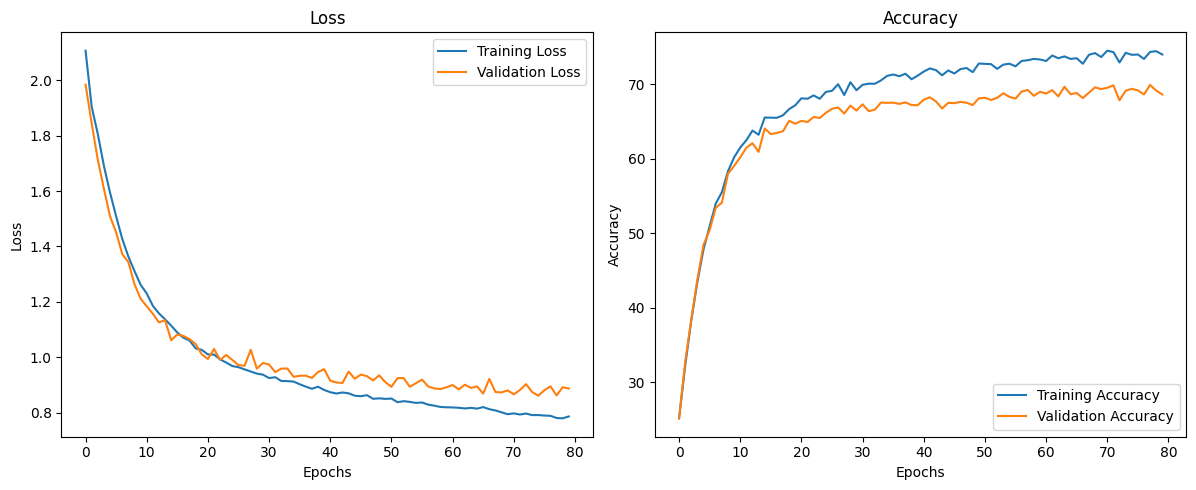

In [12]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show() 
    # plt.savefig() 

plot_history(history)

In [14]:
%watermark -iv

matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.2.2
sklearn    : 1.6.1
torch      : 2.8.0+cu126
torchinfo  : 1.8.0
torchvision: 0.23.0+cu126

